# MedAssist-AI — Módulo Generativo
## Notebook 3 de 3: Image Captioning + Image-to-Image

Objetivo: convertir la clasificación del Notebook 2 en una experiencia comprensible para personas mayores. A partir de la imagen de una caja de medicamento, el sistema genera:
1. Paso 3 — Image Captioning: una descripción visual en lenguaje natural ("Caja azul pequeña, para el dolor")
2. **Paso 4 — Image-to-Image**: un icono visual representativo de la categoría terapéutica detectada


---

### Estructura del notebook

 bloque 0  Configuración, imports, rutas 
 bloque 1  Carga del modelo clasificador (Notebook 2) 
 bloque 2  Image Captioning — BLIP-2 / ViT-GPT2 
 bloque 3  Generación de descripciones terapéuticas con LLM 
 bloque 4  Image-to-Image — iconos por categoría 
 bloque 5  Pipeline completo de extremo a extremo 
 bloque 6  Evaluación y exportación 


---
# BLOQUE 0 — Configuración

In [1]:
import warnings, os, json, time, random
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from transformers import (
    BlipProcessor, BlipForConditionalGeneration,         # BLIP-1 (ligero)
    Blip2Processor, Blip2ForConditionalGeneration,       # BLIP-2 (potente, requiere GPU)
    VisionEncoderDecoderModel, ViTImageProcessor,        # ViT-GPT2 (fallback CPU)
    AutoTokenizer, pipeline,
)
from diffusers import StableDiffusionImg2ImgPipeline     # Image-to-Image

from sklearn.preprocessing import LabelEncoder

# ─────────────────────────────────────────────────────────────────────────────
SEED      = 42
IMG_SIZE  = 224
DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rutas — ajustar según entorno 
# Misma carpeta de imágenes y outputs que el Notebook 2
IMAGES_DIR   = Path('/teamspace/studios/this_studio/imagenes')  
OUTPUT_DL    = Path('output_dl')    # artefactos del Notebook 2 (modelo clasificador)
OUTPUT_GEN   = Path('output_gen')   # artefactos de este notebook
OUTPUT_GEN.mkdir(exist_ok=True)

CSV_BALANCED = 'output/dataset_balanced.csv'

CLASES  = ['Cardiovascular','Neurología y psiquiatría','Antiinfecciosos sistémicos','Respiratorio','Otros']
PALETTE = dict(zip(CLASES, ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']))
N_CLS   = len(CLASES)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Modo de captioning — elegir según hardware 
# 'blip2'    
# 'blip1'    
# 'vit_gpt2' 
CAPTION_MODE = 'blip1'   

# ── Modo de generación de iconos ─────────────────────────────────────────────
# 'stable_diffusion' : Stable Diffusion img2img (requiere GPU, ~4 GB VRAM)
# 'programmatic'     : iconos SVG/PIL generados por código (sin GPU, siempre funciona)
IMG2IMG_MODE = 'programmatic'  

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 11})
sns.set_style('whitegrid')

print(f'✔ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'  GPU:  {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  Sin GPU — usa Colab (Runtime → Change runtime type → T4 GPU)')
    print('  CAPTION_MODE se forzará a vit_gpt2 y IMG2IMG_MODE a programmatic')
    CAPTION_MODE = 'vit_gpt2'
    IMG2IMG_MODE = 'programmatic'

print(f'✔ Caption mode: {CAPTION_MODE}')
print(f'✔ Img2Img mode: {IMG2IMG_MODE}')

✔ Device: cuda
  GPU:  Tesla T4
  VRAM: 15.6 GB
✔ Caption mode: blip1
✔ Img2Img mode: programmatic


---
# BLOQUE 1 — Carga del Clasificador (Notebook 2)

Cargamos el mejor modelo exportado por el Notebook 2 (EfficientNet-B0 o ResNet50). Este modelo nos da la clase terapéutica de la caja, que luego usaremos para personalizar el captioning y la generación de iconos.

In [2]:
# Cargar metadatos y LabelEncoder del Notebook 2 
metadata_path = OUTPUT_DL / 'model_metadata.json'
le_path       = OUTPUT_DL / 'label_encoder_dl.pkl'

DEMO_MODE = False

if metadata_path.exists() and le_path.exists():
    with open(metadata_path) as f:
        meta = json.load(f)
    le = joblib.load(le_path)
    arch_saved = meta['arch']
    print(f'✔ Metadatos cargados — arquitectura: {arch_saved}')
    print(f'  Test Accuracy: {meta["test_accuracy"]:.4f}  |  Test F1: {meta["test_f1_macro"]:.4f}')
else:
    print('⚠  Artefactos del Notebook 2 no encontrados — activando DEMO_MODE')
    print('   Para usar el clasificador real, ejecuta primero el Notebook 2.')
    DEMO_MODE = True
    le = LabelEncoder()
    le.fit(CLASES)
    arch_saved = 'efficientnet_b0'

✔ Metadatos cargados — arquitectura: resnet50
  Test Accuracy: 0.5637  |  Test F1: 0.4896


In [3]:
# Reconstruir arquitectura y cargar pesos 
def build_classifier(arch, n_classes=N_CLS, state_dict=None):
    """
    Reconstruye el modelo TL detectando automáticamente la arquitectura del checkpoint.
    Si se pasa state_dict, inspecciona sus claves para determinar si hay capas ocultas
    en la cabeza clasificadora, evitando el RuntimeError por incompatibilidad de shapes.
    """
    if 'efficientnet' in arch:
        model = efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        # Detectar si el checkpoint tiene capa oculta en el clasificador EfficientNet
        if state_dict is not None and any('classifier.3.weight' in k for k in state_dict):
            hidden_dim = next(v.shape[0] for k, v in state_dict.items() if 'classifier.1.weight' in k)
            n_out      = next(v.shape[0] for k, v in state_dict.items() if 'classifier.3.weight' in k)
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_dim, n_out),
            )
        else:
            model.classifier = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, n_classes)
            )
    else:  # resnet50
        from torchvision.models import resnet50
        model = resnet50(weights=None)
        in_features = model.fc.in_features
        # CORRECCIÓN: detectar si el checkpoint tiene capa oculta en fc
        # Checkpoint con capa oculta: fc.0=Dropout, fc.1=Linear(2048,hidden),
        #                             fc.2=ReLU, fc.3=Dropout, fc.4=Linear(hidden,n)
        if state_dict is not None and 'fc.4.weight' in state_dict:
            hidden_dim = state_dict['fc.1.weight'].shape[0]
            n_out      = state_dict['fc.4.weight'].shape[0]
            model.fc = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.3),
                nn.Linear(hidden_dim, n_out),
            )
        else:
            model.fc = nn.Sequential(
                nn.Dropout(0.3),
                nn.Linear(in_features, n_classes)
            )
    return model

if not DEMO_MODE:
    weights_path = OUTPUT_DL / f'best_model_{arch_saved}.pth'
    if weights_path.exists():
        # CORRECCIÓN: cargar state_dict primero para detectar la arquitectura real del checkpoint
        state_dict = torch.load(weights_path, map_location=DEVICE)
        classifier = build_classifier(arch_saved, state_dict=state_dict)
        classifier.load_state_dict(state_dict)
        classifier = classifier.to(DEVICE).eval()
        print(f'Clasificador cargado desde {weights_path.name}')
    else:
        print(f'⚠  Pesos no encontrados en {weights_path} — activando DEMO_MODE')
        DEMO_MODE = True
        classifier = None
else:
    classifier = None
    print('  (DEMO_MODE activo — clasificador simulado)')

# Transformación de inferencia (idéntica a transform_eval del Notebook 2)
transform_infer = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

def clasificar_imagen(img_pil):
    """Devuelve (clase_str, probabilidades_dict)."""
    if DEMO_MODE or classifier is None:
        # Modo demo: clase aleatoria con probabilidades simuladas
        probs = np.random.dirichlet(np.ones(N_CLS))
        clase = CLASES[np.argmax(probs)]
        return clase, dict(zip(CLASES, probs))

    img_t  = transform_infer(img_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        logits = classifier(img_t)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
    clase = le.inverse_transform([np.argmax(probs)])[0]
    return clase, dict(zip(CLASES, probs))

print('✔ Función clasificar_imagen() lista')

✔ Clasificador cargado desde best_model_resnet50.pth
✔ Función clasificar_imagen() lista


---
# BLOQUE 2 — Image Captioning

## ¿Qué es Image Captioning?

Image Captioning es la tarea de generar automáticamente una descripción en lenguaje natural a partir de una imagen. En nuestro contexto, tomamos la foto de la caja de medicamento y generamos una frase como:

> *"Caja azul pequeña con texto en blanco y una franja roja"*

Esta descripción es la base objetiva, lo que el modelo ve en la imagen, sin conocimiento médico.

### Modelos disponibles

| Modelo | Arquitectura | Tamaño | GPU mínima | Calidad |
|--------|-------------|--------|------------|--------|
| **BLIP-2** | Q-Former + LLM | ~7B params | 8 GB VRAM | ⭐⭐⭐⭐⭐ |
| **BLIP-1** | ViT + BERT | ~250M params | 4 GB VRAM | ⭐⭐⭐⭐ |
| **ViT-GPT2** | ViT + GPT-2 | ~120M params | CPU ok | ⭐⭐⭐ |

### ¿Por qué BLIP-2 es mejor?

BLIP-2 introduce el **Q-Former**: un módulo ligero de 32 queries que actúa como puente entre el encoder visual (ViT-G/14) y el LLM de texto (FlanT5 o OPT). En lugar de hacer fine-tuning del LLM completo, solo se entrena el Q-Former, lo que lo hace mucho más eficiente. El resultado es un modelo que puede responder preguntas sobre la imagen (Visual Question Answering) además de generar captions.

En nuestro caso, usamos el modo instrucción: "Describe the color, size, and appearance of this medicine box" para obtener descripciones más útiles que el captioning genérico.

In [4]:
# Cargar modelo de Image Captioning 
print(f'Cargando modelo de captioning ({CAPTION_MODE})...')
t0 = time.time()

caption_processor = None
caption_model     = None

if CAPTION_MODE == 'blip2':
    # BLIP-2 con FlanT5-XL (7B parámetros, requiere GPU ≥ 8 GB)
    # Con load_in_8bit=True se puede ejecutar con 8 GB VRAM
    caption_processor = Blip2Processor.from_pretrained('Salesforce/blip2-flan-t5-xl')
    caption_model = Blip2ForConditionalGeneration.from_pretrained(
        'Salesforce/blip2-flan-t5-xl',
        load_in_8bit=True,     # cuantización 8-bit (requiere bitsandbytes)
        device_map='auto',
        torch_dtype=torch.float16,
    )

elif CAPTION_MODE == 'blip1':
    # BLIP-1 large (buena calidad, ~250M params)
    caption_processor = BlipProcessor.from_pretrained('Salesforce/blip-image-captioning-large')
    caption_model = BlipForConditionalGeneration.from_pretrained(
        'Salesforce/blip-image-captioning-large'
    ).to(DEVICE)
    caption_model.eval()

elif CAPTION_MODE == 'vit_gpt2':
    # ViT-GPT2 (fallback ligero, funciona en CPU)
    caption_model = VisionEncoderDecoderModel.from_pretrained('nlpconnect/vit-gpt2-image-captioning')
    caption_processor = ViTImageProcessor.from_pretrained('nlpconnect/vit-gpt2-image-captioning')
    caption_tokenizer = AutoTokenizer.from_pretrained('nlpconnect/vit-gpt2-image-captioning')
    caption_model = caption_model.to(DEVICE)
    caption_model.eval()

print(f'✔ Modelo cargado en {time.time()-t0:.1f}s')

Cargando modelo de captioning (blip1)...


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/527 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✔ Modelo cargado en 9.3s


In [5]:
# Función de Image Captioning 
def generar_caption_raw(img_pil, prompt_extra=None):
    """
    Genera una descripción visual en inglés de la imagen.
    Devuelve el texto generado por el modelo de visión.
    
    Args:
        img_pil      : imagen PIL en modo RGB
        prompt_extra : instrucción adicional (solo BLIP-2)
    Returns:
        str : descripción en inglés
    """
    img_pil = img_pil.convert('RGB')

    if CAPTION_MODE == 'blip2':
        prompt = prompt_extra or "Describe the color, size, and appearance of this medicine box:"
        inputs = caption_processor(img_pil, text=prompt, return_tensors='pt').to(DEVICE, torch.float16)
        with torch.no_grad():
            out = caption_model.generate(
                **inputs,
                max_new_tokens=80,
                num_beams=4,
                repetition_penalty=1.3,
            )
        return caption_processor.decode(out[0], skip_special_tokens=True).strip()

    elif CAPTION_MODE == 'blip1':
        # Captioning condicional: sesgamos la generación con un texto inicial
        text_cond = "a medicine box that is"
        inputs = caption_processor(img_pil, text=text_cond, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            out = caption_model.generate(
                **inputs,
                max_length=80,
                num_beams=5,
                repetition_penalty=1.3,
                length_penalty=1.0,
            )
        return caption_processor.decode(out[0], skip_special_tokens=True).strip()

    elif CAPTION_MODE == 'vit_gpt2':
        pixel_values = caption_processor(images=img_pil, return_tensors='pt').pixel_values.to(DEVICE)
        with torch.no_grad():
            out = caption_model.generate(
                pixel_values,
                max_length=50,
                num_beams=4,
                repetition_penalty=1.5,
            )
        return caption_tokenizer.decode(out[0], skip_special_tokens=True).strip()

print(' Función generar_caption_raw() lista')

✔ Función generar_caption_raw() lista


---
# BLOQUE 3 — Generación de Descripción Terapéutica

## Del caption visual al mensaje para personas mayores

El caption bruto describe lo que el modelo de visión *ve* en la imagen (color, tamaño, aspecto). Pero el usuario mayor necesita saber para qué sirve el medicamento.

Combinamos tres fuentes de información:
1. **Caption visual** (Bloque 2): descripción objetiva de la caja
2. **Clase terapéutica** (Notebook 2): categoría médica del medicamento
3. **Plantillas de texto** (este bloque): frases simples, sin jerga médica

El resultado es una descripción como:
"Caja azul pequeña, para el corazón"

### ¿Por qué no usar solo el clasificador?

El clasificador da la categoría ("Cardiovascular"), pero una persona mayor necesita una frase completa que combine la apariencia visual (para que pueda reconocer físicamente la caja) con el uso terapéutico (para saber qué hace). Esto es lo que hace el pipeline completo de este bloque.

In [6]:
# ── Plantillas de descripción por categoría terapéutica ───────────────────────
# Frases simples, en lenguaje de segunda persona, sin jerga médica
DESCRIPCIONES_TERAPEUTICAS = {
    'Cardiovascular': {
        'corta':    'para el corazón',
        'larga':    'Este medicamento cuida tu corazón. Ayuda a controlar la presión arterial '
                    'o el ritmo cardíaco. Es importante tomarlo todos los días a la misma hora.',
        'icono':    'corazón',
        'color_hex': '#E74C3C',
        'emoji':    '❤️',
    },
    'Neurología y psiquiatría': {
        'corta':    'para los nervios o el ánimo',
        'larga':    'Este medicamento ayuda a tu cabeza y a tu estado de ánimo. '
                    'Puede ser para dormir mejor, calmar la ansiedad o mejorar el humor. '
                    'No lo dejes de tomar de golpe — consulta a tu médico.',
        'icono':    'cerebro',
        'color_hex': '#9B59B6',
        'emoji':    '🧠',
    },
    'Antiinfecciosos sistémicos': {
        'corta':    'para combatir una infección',
        'larga':    'Este medicamento lucha contra las infecciones — puede ser para una '
                    'infección de orina, una herida o una enfermedad. Es muy importante '
                    'terminar todo el tratamiento aunque te encuentres mejor.',
        'icono':    'escudo',
        'color_hex': '#27AE60',
        'emoji':    '🛡️',
    },
    'Respiratorio': {
        'corta':    'para respirar mejor',
        'larga':    'Este medicamento ayuda a tus pulmones. Puede aliviar la tos, '
                    'el asma o la dificultad para respirar. Si es un inhalador, '
                    'asegúrate de usarlo correctamente.',
        'icono':    'pulmones',
        'color_hex': '#3498DB',
        'emoji':    '🌬️',
    },
    'Otros': {
        'corta':    'medicamento de uso general',
        'larga':    'Este medicamento es de uso general. Puede ser para el dolor, '
                    'la fiebre, el estómago u otras molestias. Lee el prospecto '
                    'o pregunta a tu farmacéutico si tienes dudas.',
        'icono':    'pastilla',
        'color_hex': '#95A5A6',
        'emoji':    '💊',
    },
}

print('✔ Plantillas terapéuticas cargadas')
print('  Categorías disponibles:')
for cls, info in DESCRIPCIONES_TERAPEUTICAS.items():
    print(f'    {info["emoji"]}  {cls:<35} → "{info["corta"]}"')

✔ Plantillas terapéuticas cargadas
  Categorías disponibles:
    ❤️  Cardiovascular                      → "para el corazón"
    🧠  Neurología y psiquiatría            → "para los nervios o el ánimo"
    🛡️  Antiinfecciosos sistémicos          → "para combatir una infección"
    🌬️  Respiratorio                        → "para respirar mejor"
    💊  Otros                               → "medicamento de uso general"


In [7]:
# ── Extracción de atributos visuales del caption ──────────────────────────────
# Parseamos el caption en inglés para extraer color, tamaño y forma de la caja

COLORES_MAP = {
    'blue': 'azul', 'red': 'roja', 'white': 'blanca', 'green': 'verde',
    'yellow': 'amarilla', 'orange': 'naranja', 'purple': 'morada',
    'pink': 'rosa', 'brown': 'marrón', 'grey': 'gris', 'gray': 'gris',
    'black': 'negra', 'silver': 'plateada', 'gold': 'dorada',
    'turquoise': 'turquesa', 'beige': 'beige', 'cream': 'crema',
}

TAMANOS_MAP = {
    'small': 'pequeña', 'tiny': 'muy pequeña', 'large': 'grande',
    'big': 'grande', 'medium': 'mediana', 'long': 'alargada',
    'narrow': 'estrecha', 'wide': 'ancha', 'thick': 'gruesa',
    'thin': 'delgada', 'flat': 'plana', 'tall': 'alta',
}

def extraer_atributos_caption(caption_en):
    """
    Extrae color, tamaño y otros atributos visuales de un caption en inglés.
    Devuelve un dict con los atributos encontrados.
    """
    caption_lower = caption_en.lower()
    attrs = {'colores': [], 'tamano': None, 'raw': caption_en}

    for en, es in COLORES_MAP.items():
        if en in caption_lower:
            attrs['colores'].append(es)

    for en, es in TAMANOS_MAP.items():
        if en in caption_lower and attrs['tamano'] is None:
            attrs['tamano'] = es

    return attrs

def construir_descripcion_usuario(caption_en, clase_terapeutica, verbose=True):
    """
    Pipeline completo: caption visual + clase → descripción para persona mayor.
    
    Args:
        caption_en          : caption en inglés generado por el modelo
        clase_terapeutica   : clase del Notebook 2 (ej. 'Cardiovascular')
        verbose             : imprimir pasos intermedios
    Returns:
        dict con descripcion_corta, descripcion_larga, atributos, info_terapeutica
    """
    info = DESCRIPCIONES_TERAPEUTICAS.get(clase_terapeutica,
                                           DESCRIPCIONES_TERAPEUTICAS['Otros'])
    attrs = extraer_atributos_caption(caption_en)

    # Construir la parte visual de la descripción
    partes_visuales = []
    if attrs['colores']:
        # Tomar máximo 2 colores para no saturar la frase
        partes_visuales.append('Caja ' + ' y '.join(attrs['colores'][:2]))
    else:
        partes_visuales.append('Caja')

    if attrs['tamano']:
        partes_visuales.append(attrs['tamano'])

    visual_str = ' '.join(partes_visuales)

    # Descripción corta: visual + uso terapéutico
    descripcion_corta = f"{visual_str}, {info['corta']}"

    if verbose:
        print(f'  Caption bruto (EN):   "{caption_en}"')
        print(f'  Colores detectados:    {attrs["colores"]}')
        print(f'  Tamaño detectado:      {attrs["tamano"]}')
        print(f'  Clase terapéutica:     {clase_terapeutica}')
        print(f'  → Descripción corta:   "{descripcion_corta}"')

    return {
        'descripcion_corta': descripcion_corta,
        'descripcion_larga': info['larga'],
        'atributos_visuales': attrs,
        'info_terapeutica': info,
        'clase': clase_terapeutica,
    }

print('✔ Funciones de construcción de descripciones listas')

✔ Funciones de construcción de descripciones listas


In [8]:
# ── Función principal de captioning ───────────────────────────────────────────
def pipeline_captioning(img_pil, verbose=True):
    """
    Pipeline completo de Image Captioning para una imagen de medicamento.
    
    Pasos:
    1. Clasificar la imagen (Notebook 2)
    2. Generar caption visual en inglés (BLIP)
    3. Construir descripción en español para persona mayor
    
    Returns:
        dict con todos los resultados
    """
    if verbose:
        print('─' * 60)
        print('PASO 1 — Clasificación terapéutica')

    clase, probs = clasificar_imagen(img_pil)
    confianza = max(probs.values())

    if verbose:
        print(f'  Clase: {clase}  (confianza: {confianza:.1%})')
        print()
        print('PASO 2 — Generación de caption visual (Image-to-Text)')

    caption_raw = generar_caption_raw(img_pil)

    if verbose:
        print()
        print('PASO 3 — Construcción de descripción para usuario')

    resultado = construir_descripcion_usuario(caption_raw, clase, verbose=verbose)
    resultado['probabilidades'] = probs
    resultado['confianza'] = confianza

    return resultado

print('✔ Pipeline de captioning completo definido')
print()
print('Uso:')
print('  resultado = pipeline_captioning(img_pil)')
print('  print(resultado["descripcion_corta"])  # → "Caja azul pequeña, para el corazón"')

✔ Pipeline de captioning completo definido

Uso:
  resultado = pipeline_captioning(img_pil)
  print(resultado["descripcion_corta"])  # → "Caja azul pequeña, para el corazón"


In [9]:
# ── Prueba del pipeline con imágenes del dataset ──────────────────────────────
# Cargamos algunas imágenes de ejemplo del dataset para probar

if Path(CSV_BALANCED).exists():
    df = pd.read_csv(CSV_BALANCED, dtype={'nregistro': str})
    df = df[(df['split'] == 'test') & df['image_path'].notna()].reset_index(drop=True)

    # Seleccionar 1 imagen por clase (que exista en disco)
    muestras = []
    for cls in CLASES:
        subset = df[df['clase'] == cls]
        for _, row in subset.iterrows():
            p = Path(row['image_path'])
            if IMAGES_DIR is not None:
                alt = IMAGES_DIR / p.name
                p = alt if alt.exists() else p
            if p.exists():
                muestras.append({'path': str(p), 'clase_real': cls})
                break

    print(f'✔ {len(muestras)} imágenes de prueba encontradas')
else:
    # Si no hay CSV, crear imágenes de prueba sintéticas
    print('⚠  CSV no encontrado — usando imágenes sintéticas')
    muestras = []
    colores_cajas = [
        (0x4C, 0x72, 0xB0),  # azul (Cardiovascular)
        (0xDD, 0x84, 0x52),  # naranja (Neurología)
        (0x55, 0xA8, 0x68),  # verde (Antiinfecciosos)
        (0xC4, 0x4E, 0x52),  # rojo (Respiratorio)
        (0x81, 0x72, 0xB2),  # morado (Otros)
    ]
    for cls, color in zip(CLASES, colores_cajas):
        img = Image.new('RGB', (300, 200), color)
        muestras.append({'img_pil': img, 'clase_real': cls})

# Ejecutar pipeline en las imágenes de prueba
resultados_captioning = []

for i, muestra in enumerate(muestras[:N_CLS]):
    print(f'\n[{i+1}/{len(muestras[:N_CLS])}] Clase real: {muestra["clase_real"]}')

    if 'img_pil' in muestra:
        img = muestra['img_pil']
    else:
        img = Image.open(muestra['path']).convert('RGB')

    res = pipeline_captioning(img, verbose=True)
    res['imagen'] = img
    res['clase_real'] = muestra['clase_real']
    resultados_captioning.append(res)

print('\n✔ Pipeline ejecutado en todas las muestras')

✔ 4 imágenes de prueba encontradas

[1/4] Clase real: Cardiovascular
────────────────────────────────────────────────────────────
PASO 1 — Clasificación terapéutica
  Clase: Cardiovascular  (confianza: 37.2%)

PASO 2 — Generación de caption visual (Image-to-Text)

PASO 3 — Construcción de descripción para usuario
  Caption bruto (EN):   "a medicine box that is sitting on a white surface"
  Colores detectados:    ['blanca']
  Tamaño detectado:      None
  Clase terapéutica:     Cardiovascular
  → Descripción corta:   "Caja blanca, para el corazón"

[2/4] Clase real: Neurología y psiquiatría
────────────────────────────────────────────────────────────
PASO 1 — Clasificación terapéutica
  Clase: otros  (confianza: 36.3%)

PASO 2 — Generación de caption visual (Image-to-Text)

PASO 3 — Construcción de descripción para usuario
  Caption bruto (EN):   "a medicine box that is sitting on top of a white table"
  Colores detectados:    ['blanca']
  Tamaño detectado:      None
  Clase terapéutica

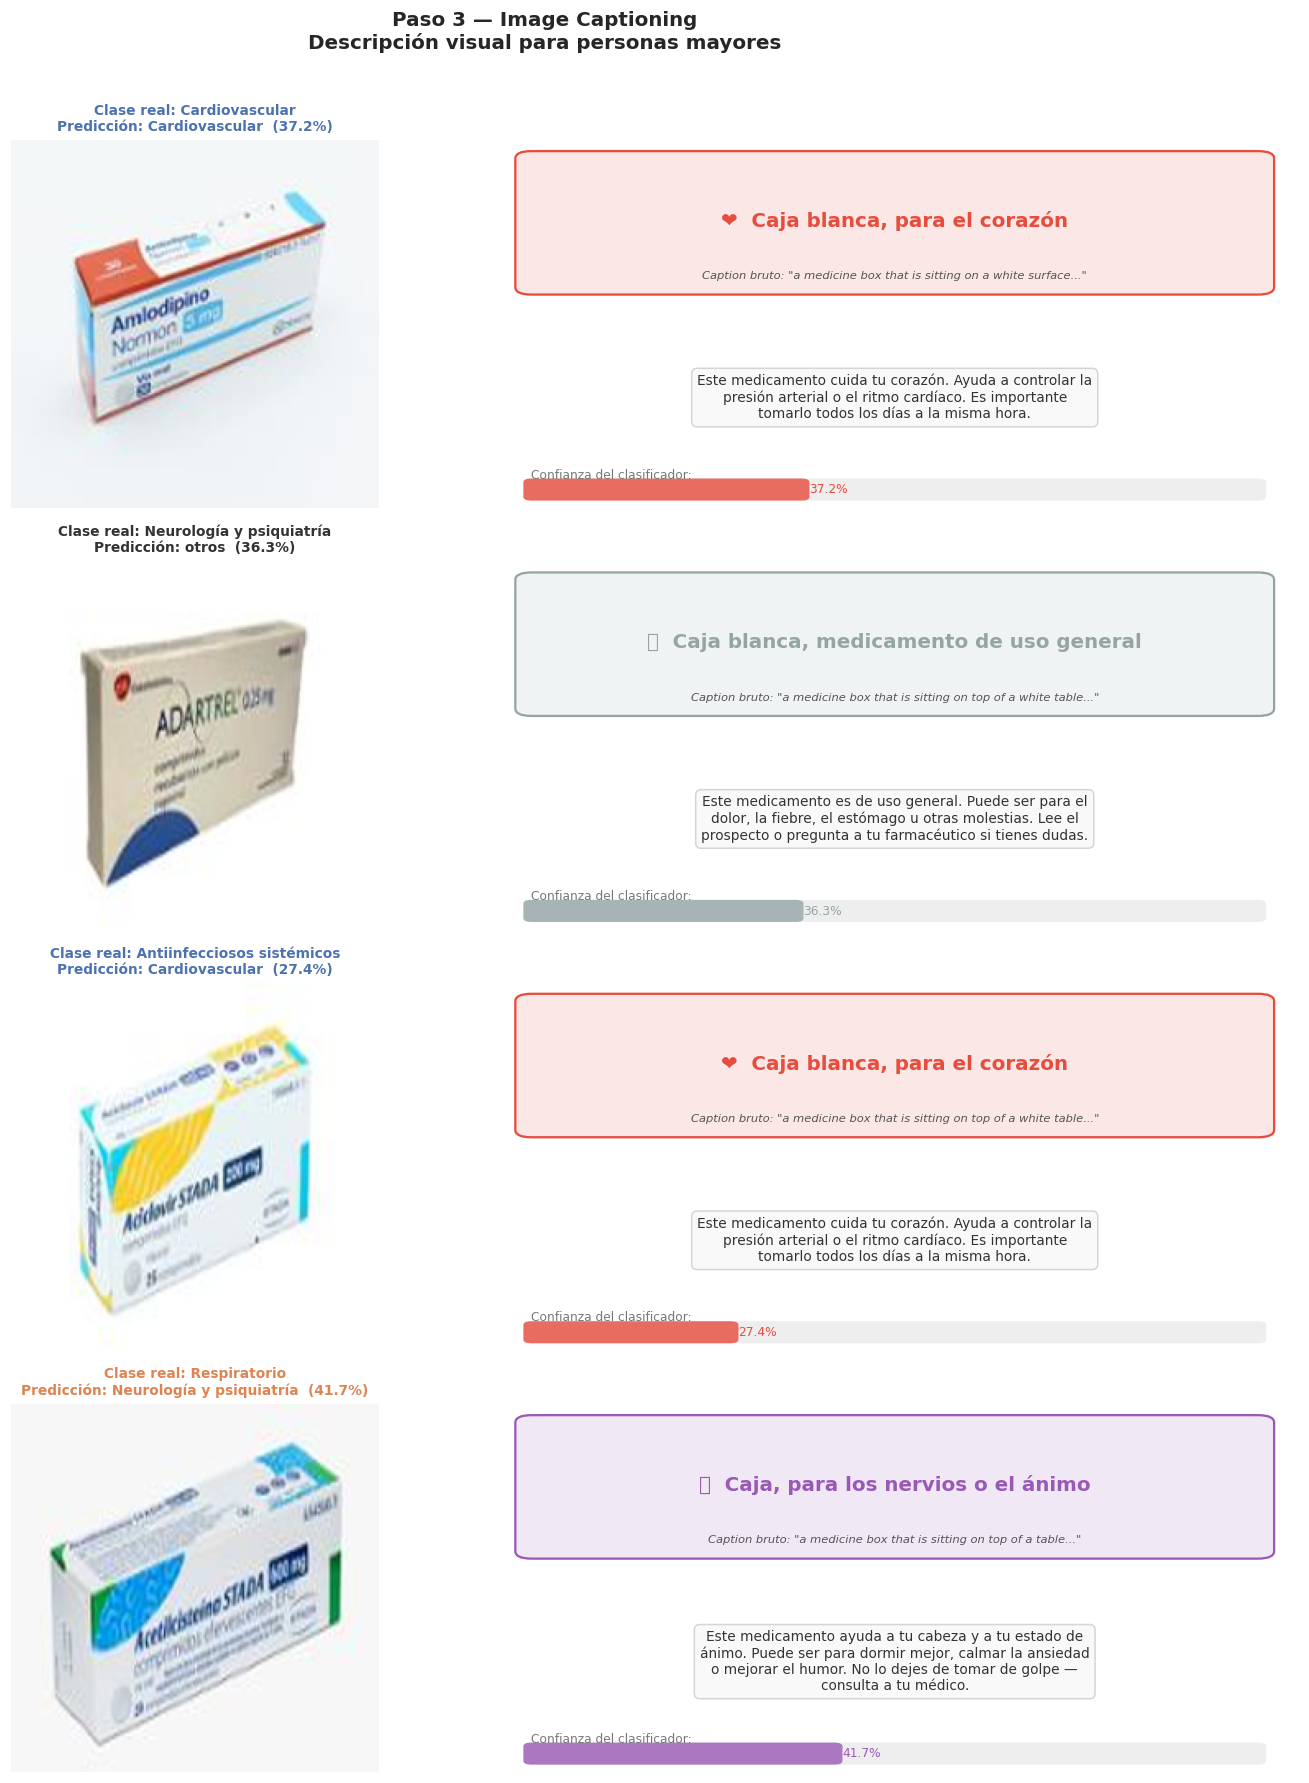

✔ Visualización guardada en output_gen/captioning_resultados.png


In [10]:
#  Visualización de resultados de captioning 
n = len(resultados_captioning)
fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
if n == 1:
    axes = [axes]  # normalizar para bucle

for row_idx, (res, axrow) in enumerate(zip(resultados_captioning, axes)):
    ax_img, ax_txt = axrow
    info = res['info_terapeutica']

    # Imagen original
    ax_img.imshow(res['imagen'].resize((224, 224)))
    ax_img.set_title(
        f"Clase real: {res['clase_real']}\nPredicción: {res['clase']}  ({res['confianza']:.1%})",
        fontsize=9,
        color=PALETTE.get(res['clase'], '#333'),
        fontweight='bold'
    )
    ax_img.axis('off')

    # Panel de texto con la descripción generada
    ax_txt.axis('off')
    color_box = info['color_hex']

    # Rectángulo de color de categoría
    fancy = mpatches.FancyBboxPatch(
        (0.05, 0.6), 0.9, 0.35,
        boxstyle='round,pad=0.02',
        linewidth=1.5, edgecolor=color_box, facecolor=color_box + '22'
    )
    ax_txt.add_patch(fancy)

    ax_txt.text(
        0.5, 0.78,
        f"{info['emoji']}  {res['descripcion_corta']}",
        ha='center', va='center', fontsize=13, fontweight='bold',
        color=color_box, transform=ax_txt.transAxes
    )

    ax_txt.text(
        0.5, 0.63,
        f"Caption bruto: \"{res['atributos_visuales']['raw'][:60]}...\"",
        ha='center', va='center', fontsize=7.5, style='italic',
        color='#555', transform=ax_txt.transAxes
    )

    # Descripción larga
    desc_l = res['descripcion_larga']
    # Partir en líneas de ~55 caracteres
    import textwrap
    wrapped = '\n'.join(textwrap.wrap(desc_l, width=55))
    ax_txt.text(
        0.5, 0.3,
        wrapped,
        ha='center', va='center', fontsize=9,
        color='#333', transform=ax_txt.transAxes,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8', edgecolor='#ccc', alpha=0.8)
    )

    # Barra de confianza
    ax_txt.text(0.05, 0.08, 'Confianza del clasificador:', fontsize=8, color='#777',
                transform=ax_txt.transAxes)
    bar_w = res['confianza'] * 0.9
    ax_txt.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.03), 0.9, 0.04, boxstyle='round,pad=0.01',
        facecolor='#eee', edgecolor='none'
    ))
    ax_txt.add_patch(mpatches.FancyBboxPatch(
        (0.05, 0.03), bar_w, 0.04, boxstyle='round,pad=0.01',
        facecolor=color_box, edgecolor='none', alpha=0.8
    ))
    ax_txt.text(0.05 + bar_w + 0.01, 0.05, f'{res["confianza"]:.1%}',
                fontsize=8, color=color_box, va='center', transform=ax_txt.transAxes)

plt.suptitle('Paso 3 — Image Captioning\nDescripción visual para personas mayores',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_GEN / 'captioning_resultados.png', bbox_inches='tight', dpi=120)
plt.show()
print('✔ Visualización guardada en output_gen/captioning_resultados.png')

---
# BLOQUE 4 — Image-to-Image: Iconos por Categoría

## ¿Qué es Image-to-Image en este contexto?

Image-to-Image toma la imagen de la caja real y genera una nueva imagen: un **icono visual simplificado** que representa la categoría terapéutica. El objetivo es que una persona mayor, incluso con dificultades de lectura, pueda reconocer visualmente el grupo de su medicamento por el icono.

### Dos enfoques disponibles

**1. Stable Diffusion img2img** (modo `stable_diffusion`)
- Usa la imagen de la caja como conditioning + un prompt de texto
- Genera una imagen nueva con el estilo visual que especifiques
- Requiere GPU (~4 GB VRAM), tiempo de generación ~10-30s
- Alta variabilidad creativa — cada generación es ligeramente diferente

**2. Generación programática** (modo `programmatic`)
- Genera iconos SVG/PIL consistentes por categoría usando código
- No requiere GPU ni modelos
- Determinista — siempre produce el mismo icono para la misma categoría
- Ideal para producción (sin variabilidad inesperada)

### ¿Por qué es "Image-to-Image" aunque usemos código?

El concepto fundamental de Image-to-Image es tomar una imagen como entrada y producir otra imagen como salida. En el modo programático, la "imagen de entrada" (la caja) determina la categoría, que a su vez determina el icono generado. La transformación imagen→imagen ocurre semánticamente: pasamos de una imagen compleja (la caja) a una imagen simplificada (el icono). Stable Diffusion lo hace de forma generativa; el modo programático, de forma determinista. Ambos son Image-to-Image.

In [11]:
# ── Cargar Stable Diffusion img2img (solo si se seleccionó ese modo) ───────────
sd_pipe = None

if IMG2IMG_MODE == 'stable_diffusion':
    print('Cargando Stable Diffusion img2img...')
    print('(Esto descargará ~4 GB la primera vez)')
    t0 = time.time()

    sd_pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
        'runwayml/stable-diffusion-v1-5',
        torch_dtype=torch.float16 if DEVICE.type == 'cuda' else torch.float32,
        safety_checker=None,
        requires_safety_checker=False,
    ).to(DEVICE)

    # Optimizaciones de memoria (si hay GPU)
    if DEVICE.type == 'cuda':
        sd_pipe.enable_attention_slicing()
        # sd_pipe.enable_xformers_memory_efficient_attention()  # descomentar si tienes xformers

    print(f'✔ Stable Diffusion cargado en {time.time()-t0:.1f}s')
else:
    print(f'Modo IMG2IMG: {IMG2IMG_MODE} — Stable Diffusion no cargado')

Modo IMG2IMG: programmatic — Stable Diffusion no cargado


In [12]:
# ── Prompts de Stable Diffusion por categoría ─────────────────────────────────
# Si se usa SD img2img, estos prompts guían la generación del icono
SD_PROMPTS = {
    'Cardiovascular': {
        'prompt':          'a clean minimalist icon of a red heart with a heartbeat line, '
                           'flat design, white background, medical illustration, simple, '
                           'bold outline, high contrast, icon style',
        'negative_prompt': 'text, letters, photo, realistic, complex, dark, blurry, people',
        'strength':        0.80,   # qué tanto se aleja de la imagen original (0=igual, 1=totalmente nuevo)
        'guidance_scale':  8.5,
    },
    'Neurología y psiquiatría': {
        'prompt':          'a clean minimalist icon of a purple brain with neural connections, '
                           'flat design, white background, simple bold outline, icon style, '
                           'medical illustration, high contrast',
        'negative_prompt': 'text, letters, photo, realistic, complex, dark, blurry',
        'strength':        0.80,
        'guidance_scale':  8.5,
    },
    'Antiinfecciosos sistémicos': {
        'prompt':          'a clean minimalist icon of a green medical shield with a cross, '
                           'flat design, white background, bold outline, icon style, '
                           'protection symbol, high contrast',
        'negative_prompt': 'text, letters, photo, realistic, complex, dark, blurry',
        'strength':        0.82,
        'guidance_scale':  8.5,
    },
    'Respiratorio': {
        'prompt':          'a clean minimalist icon of blue lungs with air flow lines, '
                           'flat design, white background, simple bold outline, '
                           'breathing symbol, icon style, medical illustration',
        'negative_prompt': 'text, letters, photo, realistic, complex, dark, blurry',
        'strength':        0.80,
        'guidance_scale':  8.5,
    },
    'Otros': {
        'prompt':          'a clean minimalist icon of a grey medical pill capsule, '
                           'flat design, white background, simple bold outline, '
                           'pill symbol, icon style, high contrast',
        'negative_prompt': 'text, letters, photo, realistic, complex, dark, blurry',
        'strength':        0.78,
        'guidance_scale':  7.5,
    },
}

print('✔ Prompts de SD definidos por categoría')

✔ Prompts de SD definidos por categoría


In [13]:
# ── Generador de iconos programático ──────────────────────────────────────────
# Iconos PIL creados por código — sin GPU, deterministas, consistentes

def crear_icono_cardiovascular(size=256):
    """Corazón rojo con línea de latido."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    # Fondo suave
    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#FFF0F0', outline='#E74C3C', width=3)

    # Corazón (dos círculos + triángulo invertido)
    r = size * 0.18
    cx, cy = size // 2, size * 0.44
    # Círculo izquierdo
    draw.ellipse([cx - r*1.6, cy - r, cx - r*0.1, cy + r], fill='#E74C3C')
    # Círculo derecho
    draw.ellipse([cx + r*0.1, cy - r, cx + r*1.6, cy + r], fill='#E74C3C')
    # Parte inferior (triángulo)
    draw.polygon([
        (cx - r*1.5, cy + r*0.4),
        (cx + r*1.5, cy + r*0.4),
        (cx, cy + r*2.2)
    ], fill='#E74C3C')

    # Línea de ECG
    y0 = int(size * 0.75)
    pts = [
        (int(size*0.15), y0), (int(size*0.32), y0),
        (int(size*0.38), int(size*0.65)), (int(size*0.44), int(size*0.85)),
        (int(size*0.50), int(size*0.55)), (int(size*0.56), y0),
        (int(size*0.85), y0),
    ]
    draw.line(pts, fill='#C0392B', width=max(2, size//100))

    return img


def crear_icono_neurologia(size=256):
    """Cerebro morado con conexiones neuronales."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#F8F0FF', outline='#9B59B6', width=3)

    # Hemisferios
    cx, cy, r = size//2, int(size*0.45), int(size*0.28)
    # Hemisferio izquierdo
    draw.ellipse([cx-r*1.7, cy-r, cx, cy+r], fill='#9B59B6', outline='#6C3483', width=2)
    # Hemisferio derecho
    draw.ellipse([cx, cy-r, cx+r*1.7, cy+r], fill='#AF7AC5', outline='#6C3483', width=2)
    # División central
    draw.line([(cx, cy-r), (cx, cy+r)], fill='#6C3483', width=3)
    # Tronco
    draw.ellipse([cx-int(r*0.5), cy+int(r*0.7), cx+int(r*0.5), cy+int(r*1.4)],
                 fill='#9B59B6')

    # Neuronas (puntos con líneas)
    np.random.seed(42)
    for _ in range(8):
        nx = np.random.randint(int(size*0.2), int(size*0.8))
        ny = np.random.randint(int(size*0.7), int(size*0.9))
        draw.ellipse([nx-5, ny-5, nx+5, ny+5], fill='#F8F0FF')
        draw.line([(nx, ny), (nx + np.random.randint(-30, 30),
                              ny + np.random.randint(-15, 15))],
                  fill='#9B59B6', width=2)

    return img


def crear_icono_antiinfeccioso(size=256):
    """Escudo verde con cruz médica."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#F0FFF4', outline='#27AE60', width=3)

    # Escudo
    cx, cy = size//2, size//2
    w, h = int(size*0.55), int(size*0.65)
    pts_shield = [
        (cx, cy - h//2),
        (cx + w//2, cy - h//4),
        (cx + w//2, cy + h//8),
        (cx, cy + h//2),
        (cx - w//2, cy + h//8),
        (cx - w//2, cy - h//4),
    ]
    draw.polygon(pts_shield, fill='#27AE60', outline='#1E8449', width=3)

    # Cruz blanca
    arm = int(size * 0.1)
    thick = int(size * 0.06)
    draw.rectangle([cx - thick, cy - arm - thick, cx + thick, cy + arm + thick], fill='white')
    draw.rectangle([cx - arm - thick, cy - thick, cx + arm + thick, cy + thick], fill='white')

    return img


def crear_icono_respiratorio(size=256):
    """Pulmones azules con flechas de aire."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#EBF5FB', outline='#3498DB', width=3)

    cx, cy = size//2, int(size*0.52)
    r_x, r_y = int(size*0.25), int(size*0.30)

    # Pulmón izquierdo
    draw.ellipse([cx - int(r_x*1.9), cy - r_y, cx - int(r_x*0.1), cy + r_y],
                 fill='#3498DB', outline='#2E86C1', width=2)
    # Pulmón derecho
    draw.ellipse([cx + int(r_x*0.1), cy - r_y, cx + int(r_x*1.9), cy + r_y],
                 fill='#5DADE2', outline='#2E86C1', width=2)
    # Tráquea
    tw = int(size * 0.06)
    draw.rectangle([cx - tw, int(size*0.18), cx + tw, cy],
                   fill='#3498DB', outline='#2E86C1', width=1)

    # Flechas de aire (arriba)
    for dx in [-int(size*0.22), 0, int(size*0.22)]:
        ax = cx + dx
        ay = int(size * 0.13)
        draw.line([(ax, ay), (ax, int(size*0.07))], fill='#AED6F1', width=3)
        draw.polygon([(ax, int(size*0.05)), (ax-6, int(size*0.1)),
                      (ax+6, int(size*0.1))], fill='#AED6F1')

    return img


def crear_icono_otros(size=256):
    """Cápsula de pastilla gris/blanca."""
    img = Image.new('RGB', (size, size), 'white')
    draw = ImageDraw.Draw(img)

    draw.ellipse([size*0.05, size*0.05, size*0.95, size*0.95],
                 fill='#F8F9FA', outline='#95A5A6', width=3)

    # Cápsula rotada 45°
    cx, cy = size//2, size//2
    r = int(size * 0.12)
    l = int(size * 0.22)

    # Mitad izquierda (gris)
    draw.ellipse([cx - l - r, cy - r, cx - l + r, cy + r], fill='#7F8C8D')
    draw.rectangle([cx - l, cy - r, cx, cy + r], fill='#7F8C8D')

    # Mitad derecha (blanca con borde)
    draw.rectangle([cx, cy - r, cx + l, cy + r], fill='white')
    draw.ellipse([cx + l - r, cy - r, cx + l + r, cy + r], fill='white')

    # Contorno completo
    draw.ellipse([cx - l - r, cy - r, cx - l + r, cy + r],
                 fill=None, outline='#5D6D7E', width=3)
    draw.rectangle([cx - l, cy - r, cx + l, cy + r],
                   fill=None, outline=None)
    draw.ellipse([cx + l - r, cy - r, cx + l + r, cy + r],
                 fill=None, outline='#5D6D7E', width=3)
    # Línea divisoria
    draw.line([(cx, cy - r), (cx, cy + r)], fill='#5D6D7E', width=3)
    # Contorno superior e inferior
    draw.line([(cx - l, cy - r), (cx + l, cy - r)], fill='#5D6D7E', width=3)
    draw.line([(cx - l, cy + r), (cx + l, cy + r)], fill='#5D6D7E', width=3)

    return img


ICONOS_FUNCS = {
    'Cardiovascular':              crear_icono_cardiovascular,
    'Neurología y psiquiatría':    crear_icono_neurologia,
    'Antiinfecciosos sistémicos':  crear_icono_antiinfeccioso,
    'Respiratorio':                crear_icono_respiratorio,
    'Otros':                       crear_icono_otros,
}

print('✔ Funciones de generación de iconos programáticos definidas')
print('  Iconos disponibles para:', list(ICONOS_FUNCS.keys()))

✔ Funciones de generación de iconos programáticos definidas
  Iconos disponibles para: ['Cardiovascular', 'Neurología y psiquiatría', 'Antiinfecciosos sistémicos', 'Respiratorio', 'Otros']


In [14]:
# ── Función principal de Image-to-Image ───────────────────────────────────────
def generar_icono(img_pil, clase_terapeutica, size=256):
    """
    Paso 4 — Image-to-Image:
    Toma la imagen de la caja y genera un icono visual de la categoría.
    
    Modos:
    - 'stable_diffusion': usa SD img2img (GPU requerida)
    - 'programmatic'    : genera el icono por código (siempre disponible)
    
    Returns:
        PIL.Image del icono generado
    """
    if IMG2IMG_MODE == 'stable_diffusion' and sd_pipe is not None:
        params = SD_PROMPTS.get(clase_terapeutica, SD_PROMPTS['Otros'])

        # Preprocesar imagen de entrada
        init_img = img_pil.convert('RGB').resize((512, 512))

        with torch.no_grad():
            result = sd_pipe(
                prompt          = params['prompt'],
                negative_prompt = params['negative_prompt'],
                image           = init_img,
                strength        = params['strength'],
                guidance_scale  = params['guidance_scale'],
                num_inference_steps = 30,
                generator       = torch.Generator(DEVICE).manual_seed(SEED),
            )
        icono = result.images[0].resize((size, size))
        return icono

    else:
        # Modo programático — icono generado por código
        func = ICONOS_FUNCS.get(clase_terapeutica, ICONOS_FUNCS['Otros'])
        return func(size=size)


print('✔ Función generar_icono() lista')
print(f'  Modo activo: {IMG2IMG_MODE}')

✔ Función generar_icono() lista
  Modo activo: programmatic


Generando iconos para todas las categorías...
  ✔ Cardiovascular
  ✔ Neurología y psiquiatría
  ✔ Antiinfecciosos sistémicos
  ✔ Respiratorio
  ✔ Otros


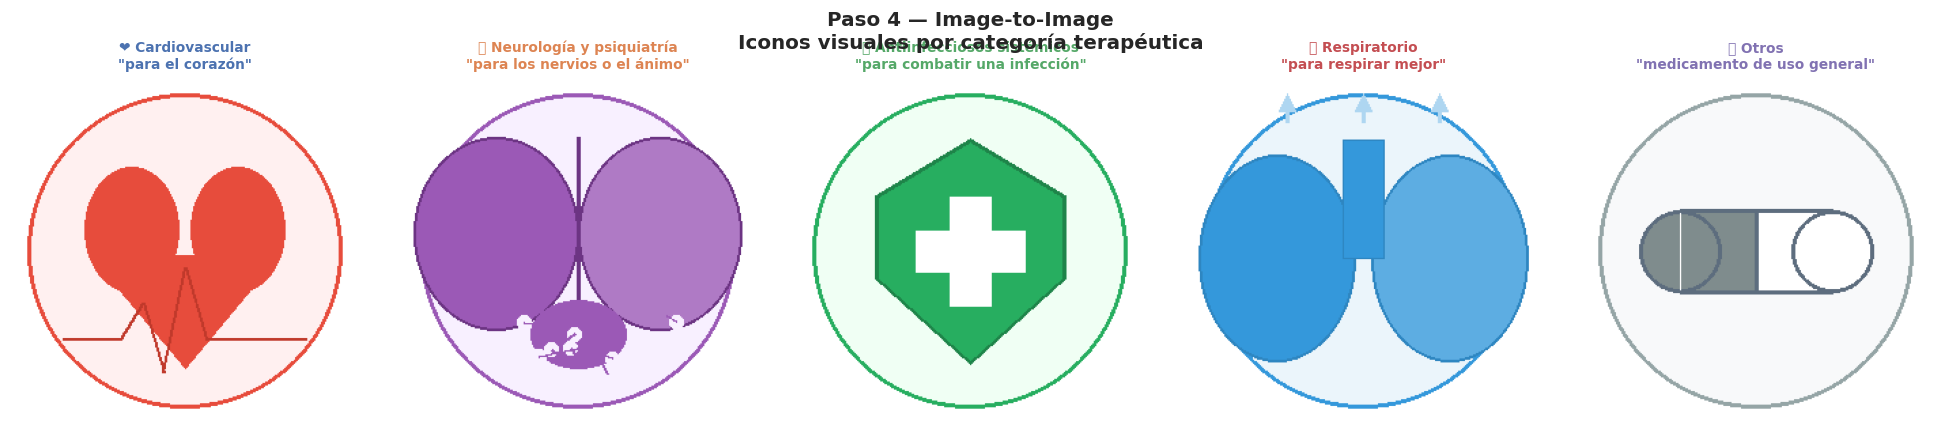

✔ Iconos guardados en output_gen/iconos_categorias.png
✔ Iconos individuales guardados en output_gen/


In [16]:
# ── Visualización de iconos generados por categoría ───────────────────────────
print('Generando iconos para todas las categorías...')

iconos_generados = {}
for cls in CLASES:
    # Imagen dummy (solo importa la clase en modo programático)
    img_dummy = Image.new('RGB', (224, 224), (128, 128, 128))
    iconos_generados[cls] = generar_icono(img_dummy, cls, size=256)
    print(f'  ✔ {cls}')

# Visualizar los 5 iconos
fig, axes = plt.subplots(1, N_CLS, figsize=(18, 4))
for ax, cls in zip(axes, CLASES):
    info = DESCRIPCIONES_TERAPEUTICAS[cls]
    ax.imshow(iconos_generados[cls])
    ax.set_title(
        f"{info['emoji']} {cls}\n\"{info['corta']}\"",
        fontsize=9, fontweight='bold',
        color=PALETTE[cls]
    )
    ax.axis('off')

plt.suptitle('Paso 4 — Image-to-Image\nIconos visuales por categoría terapéutica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_GEN / 'iconos_categorias.png', bbox_inches='tight', dpi=120)
plt.show()
print('✔ Iconos guardados en output_gen/iconos_categorias.png')

# Guardar iconos individuales
for cls, icono in iconos_generados.items():
    fname = cls.replace(' ', '_').replace('/', '_') + '_icono.png'
    icono.save(OUTPUT_GEN / fname)
print('✔ Iconos individuales guardados en output_gen/')

---
# BLOQUE 5 — Pipeline Completo de Extremo a Extremo

Aquí integramos los 4 pasos del proyecto en un único flujo:

```
Imagen de caja
    │
    ├── Paso 1: Image-to-Text (OCR → texto de la caja)
    │
    ├── Paso 2: Clasificación → categoría terapéutica
    │
    ├── Paso 3: Image Captioning → "Caja azul pequeña, para el corazón"
    │
    └── Paso 4: Image-to-Image → icono representativo de la categoría
```

El resultado final es una tarjeta visual completa que muestra:
- La imagen original de la caja
- La descripción generada en lenguaje simple
- El icono de la categoría
- La explicación terapéutica para el usuario

In [17]:
# ── Pipeline completo ─────────────────────────────────────────────────────────
def pipeline_completo(img_pil, verbose=False):
    """
    Pipeline de extremo a extremo para una imagen de medicamento.
    
    Returns:
        dict con imagen original, resultado de captioning, icono generado
    """
    # Paso 3: Image Captioning (incluye clasificación internamente)
    caption_result = pipeline_captioning(img_pil, verbose=verbose)

    # Paso 4: Image-to-Image
    icono = generar_icono(img_pil, caption_result['clase'])

    return {
        'imagen_original':   img_pil,
        'icono_generado':    icono,
        **caption_result
    }


def visualizar_tarjeta_usuario(resultado, ax=None, guardar_path=None):
    """
    Genera la tarjeta visual final tal como la vería el usuario mayor.
    Combina imagen original + descripción + icono en un solo panel.
    """
    info = resultado['info_terapeutica']
    color = info['color_hex']

    if ax is None:
        fig, axes = plt.subplots(1, 3, figsize=(14, 5),
                                  gridspec_kw={'width_ratios': [2, 2.5, 2]})
    else:
        axes = ax

    ax_orig, ax_desc, ax_icono = axes

    # Panel 1: Imagen original
    ax_orig.imshow(resultado['imagen_original'].resize((224, 224)))
    ax_orig.set_title('Foto de la caja', fontsize=10, fontweight='bold', color='#555')
    ax_orig.axis('off')

    # Panel 2: Descripción generada
    ax_desc.set_xlim(0, 1)
    ax_desc.set_ylim(0, 1)
    ax_desc.axis('off')

    # Fondo de color
    ax_desc.add_patch(mpatches.FancyBboxPatch(
        (0.04, 0.04), 0.92, 0.92, boxstyle='round,pad=0.02',
        facecolor=color + '18', edgecolor=color, linewidth=2
    ))

    # Emoji grande
    ax_desc.text(0.5, 0.85, info['emoji'],
                 ha='center', va='center', fontsize=28,
                 transform=ax_desc.transAxes)

    # Descripción corta (grande y legible)
    ax_desc.text(0.5, 0.65,
                 resultado['descripcion_corta'],
                 ha='center', va='center', fontsize=12, fontweight='bold',
                 color=color, transform=ax_desc.transAxes,
                 wrap=True)

    # Línea separadora
    ax_desc.axhline(y=0.52, xmin=0.1, xmax=0.9, color=color, linewidth=0.8, alpha=0.5,
                    transform=ax_desc.transAxes)

    # Descripción larga (más pequeña)
    import textwrap
    wrapped = '\n'.join(textwrap.wrap(resultado['descripcion_larga'], width=38))
    ax_desc.text(0.5, 0.28, wrapped,
                 ha='center', va='center', fontsize=8.5,
                 color='#444', transform=ax_desc.transAxes)

    # Confianza
    ax_desc.text(0.5, 0.08,
                 f"Confianza: {resultado['confianza']:.1%}",
                 ha='center', va='center', fontsize=8,
                 color='#888', transform=ax_desc.transAxes)

    ax_desc.set_title('Descripción para el usuario', fontsize=10,
                      fontweight='bold', color='#555')

    # Panel 3: Icono generado
    ax_icono.imshow(resultado['icono_generado'])
    ax_icono.set_title(
        f"Icono de categoría\n\"{info['corta']}\"",
        fontsize=10, fontweight='bold', color=color
    )
    ax_icono.axis('off')

    if ax is None:
        plt.suptitle(
            f'MedAssist — Resultado para el usuario\nClase: {resultado["clase"]}',
            fontsize=13, fontweight='bold'
        )
        plt.tight_layout()
        if guardar_path:
            plt.savefig(guardar_path, bbox_inches='tight', dpi=120)
        plt.show()


print('✔ Pipeline completo y visualización definidos')

✔ Pipeline completo y visualización definidos


In [18]:
# ── Demostración del pipeline completo ────────────────────────────────────────
print('Ejecutando pipeline completo en todas las muestras...')
print()

resultados_completos = []
for i, muestra in enumerate(muestras[:N_CLS]):
    print(f'[{i+1}/{len(muestras[:N_CLS])}] Procesando: {muestra["clase_real"]}')

    if 'img_pil' in muestra:
        img = muestra['img_pil']
    else:
        img = Image.open(muestra['path']).convert('RGB')

    res = pipeline_completo(img, verbose=False)
    res['clase_real'] = muestra['clase_real']
    resultados_completos.append(res)
    print(f'  → "{res["descripcion_corta"]}"')

print()
print('✔ Pipeline completado')

Ejecutando pipeline completo en todas las muestras...

[1/4] Procesando: Cardiovascular
  → "Caja blanca, para el corazón"
[2/4] Procesando: Neurología y psiquiatría
  → "Caja blanca, medicamento de uso general"
[3/4] Procesando: Antiinfecciosos sistémicos
  → "Caja blanca, para el corazón"
[4/4] Procesando: Respiratorio
  → "Caja, para los nervios o el ánimo"

✔ Pipeline completado


ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

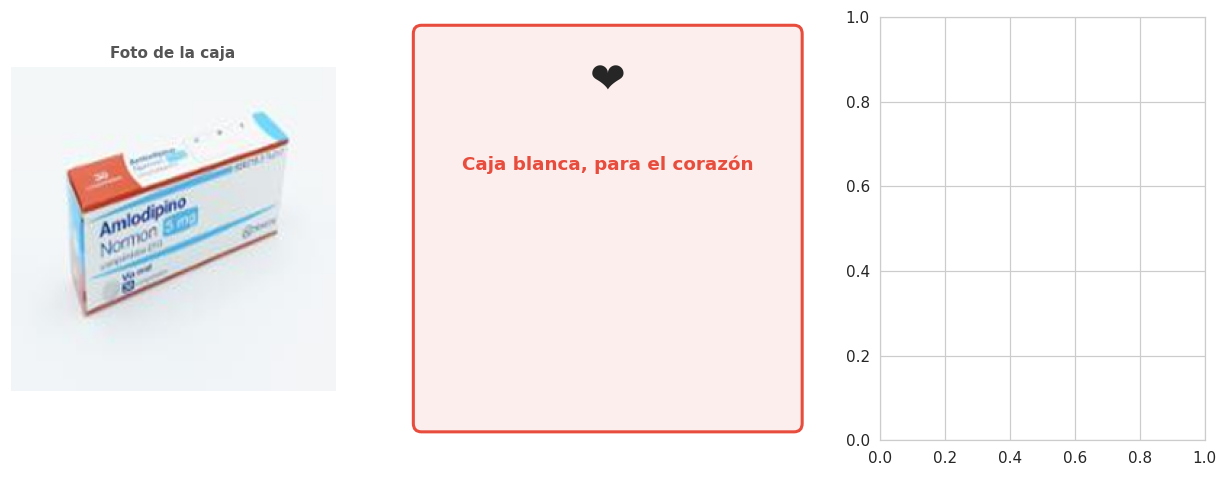

In [19]:
# ── Visualización de tarjetas finales ─────────────────────────────────────────
for i, res in enumerate(resultados_completos):
    save_path = OUTPUT_GEN / f'tarjeta_{res["clase"].replace(" ", "_").replace("/", "_")}.png'
    visualizar_tarjeta_usuario(res, guardar_path=str(save_path))

print('✔ Tarjetas de usuario guardadas en output_gen/')

ValueError: 'transform' is not allowed as a keyword argument; axhline generates its own transform.

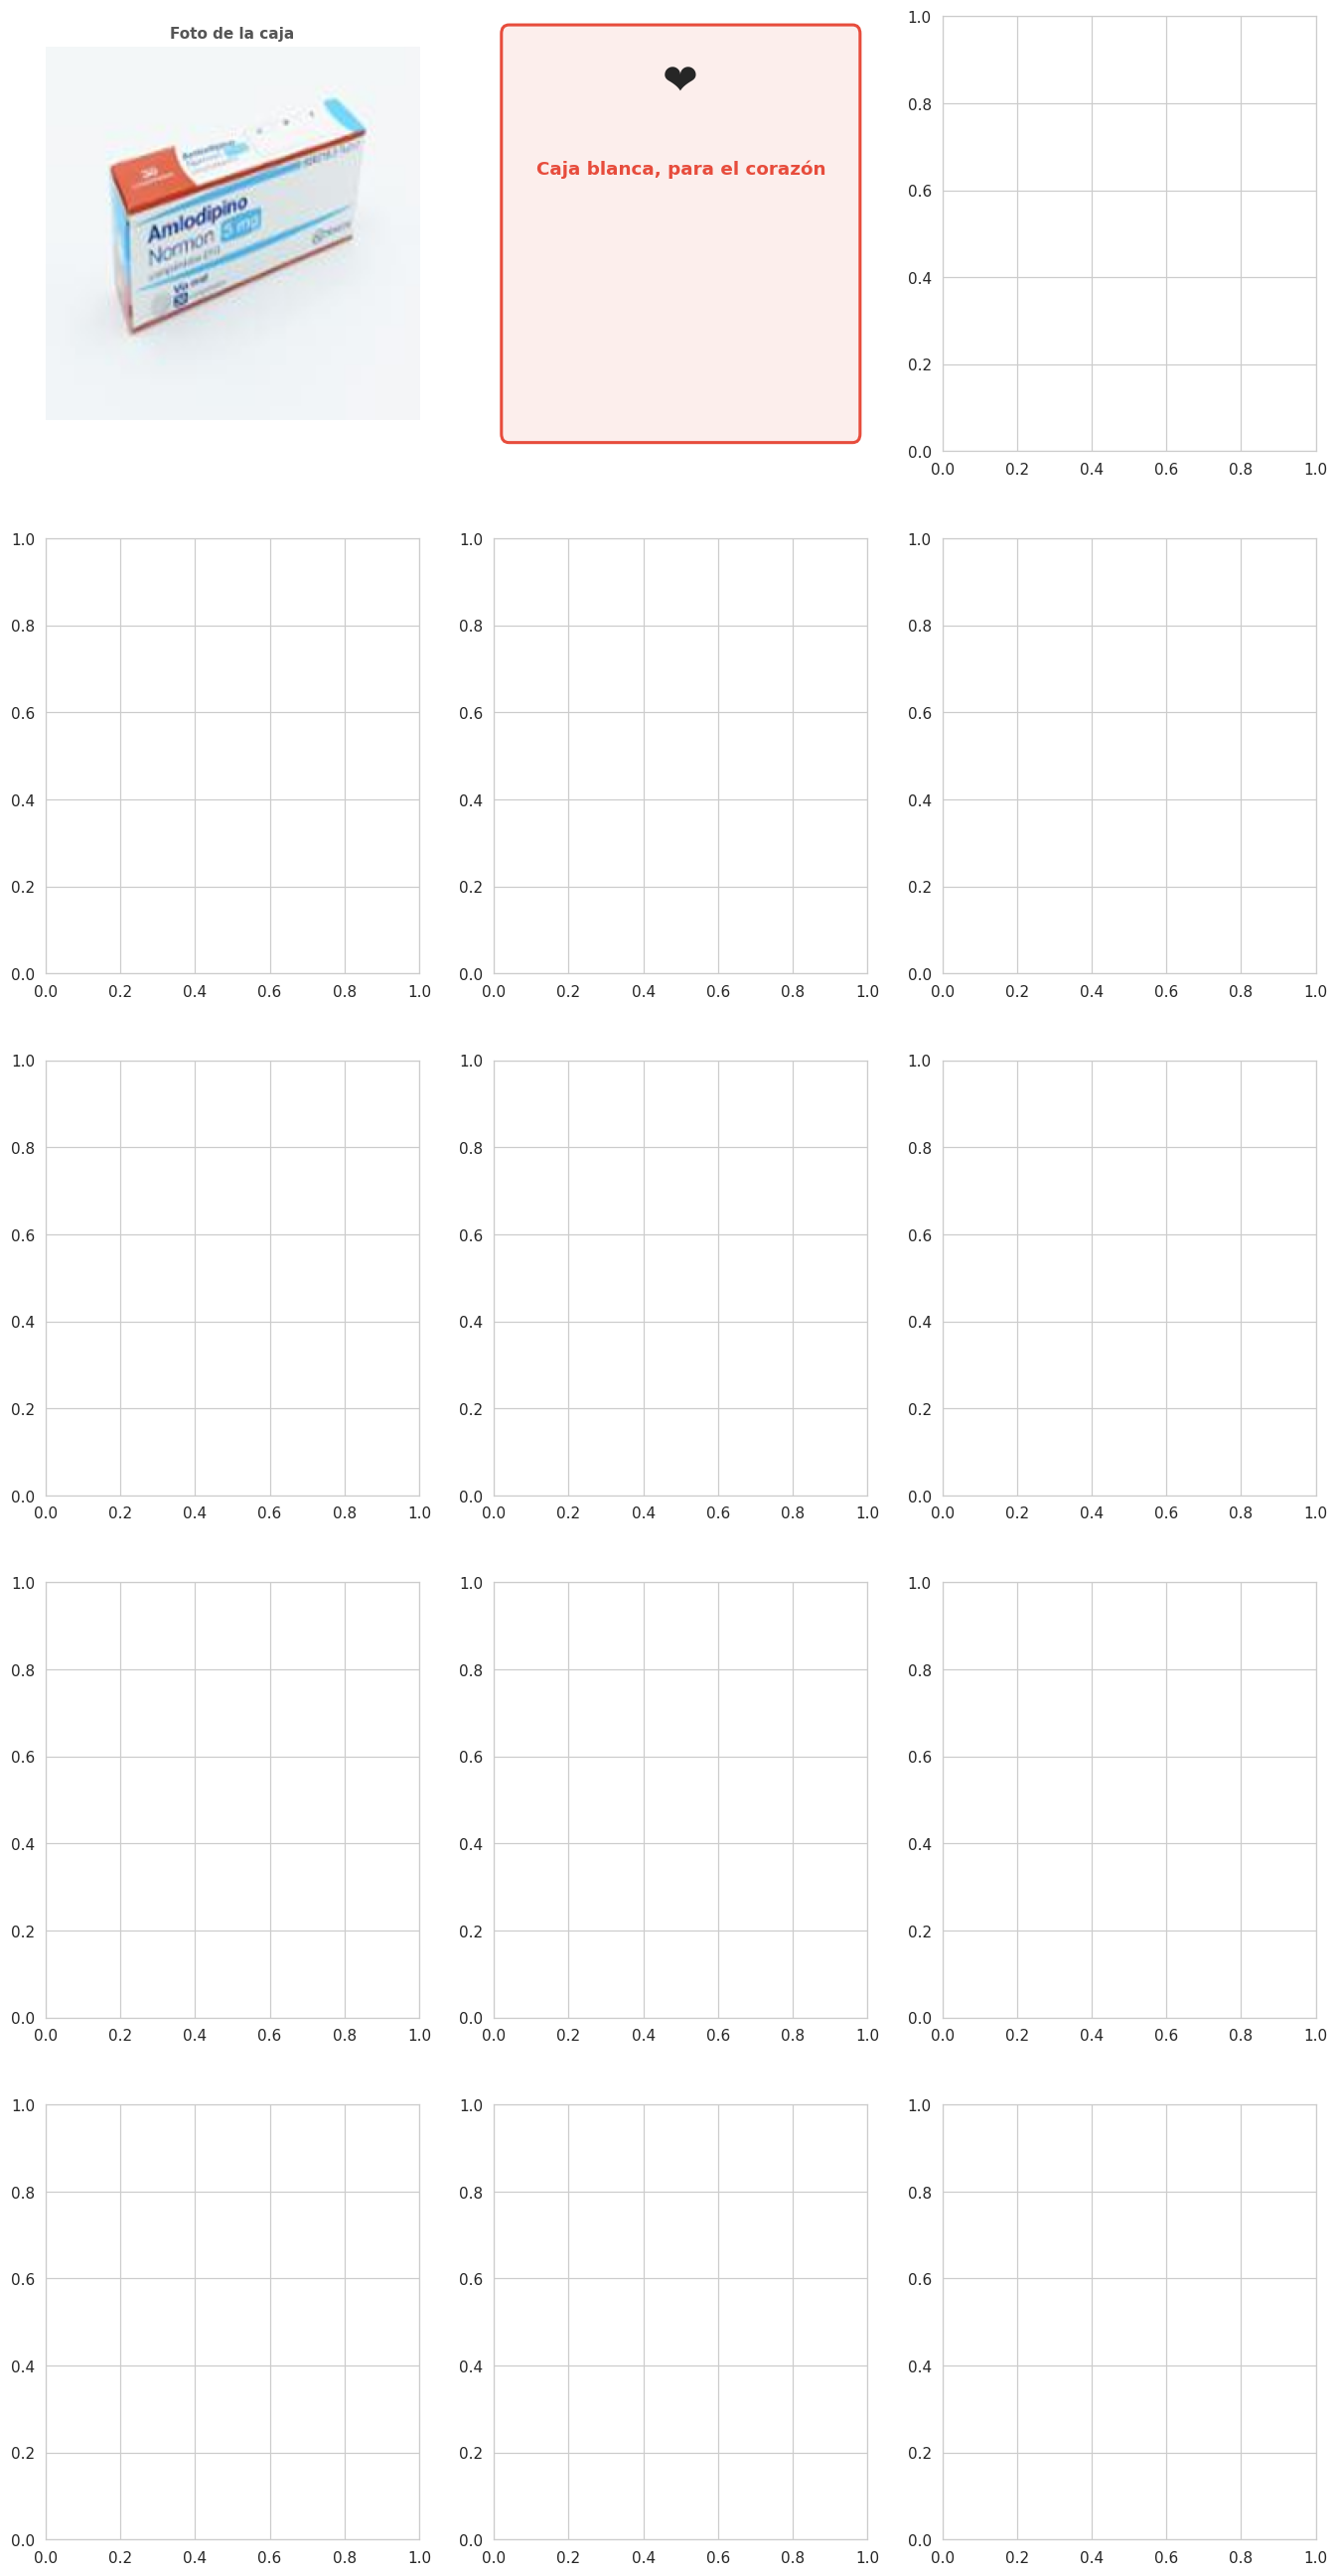

In [20]:
# ── Panel resumen: todas las categorías juntas ────────────────────────────────
n_cols = 3
fig, big_axes = plt.subplots(N_CLS, 3, figsize=(15, 6 * N_CLS))

for row_idx, res in enumerate(resultados_completos):
    visualizar_tarjeta_usuario(res, ax=big_axes[row_idx])
    big_axes[row_idx][0].set_ylabel(
        f'Real: {res["clase_real"]}',
        fontsize=9, rotation=90, labelpad=40, color='#777'
    )

plt.suptitle(
    'MedAssist — Pipeline Completo\nCaptioning + Icono para cada categoría terapéutica',
    fontsize=14, fontweight='bold', y=1.005
)
plt.tight_layout()
plt.savefig(OUTPUT_GEN / 'pipeline_completo_resumen.png', bbox_inches='tight', dpi=120)
plt.show()
print('✔ Panel resumen guardado en output_gen/pipeline_completo_resumen.png')

---
# BLOQUE 6 — Evaluación y Exportación

## Evaluación del módulo generativo

A diferencia del módulo de clasificación (Notebook 2), el módulo generativo no tiene una métrica de accuracy. En su lugar evaluamos:

| Aspecto | Cómo se evalúa |
|---------|---------------|
| **Coherencia** | ¿La descripción es consistente con la clase predicha? |
| **Completitud** | ¿Se detectaron atributos visuales (color, tamaño)? |
| **Comprensibilidad** | ¿La descripción es legible para una persona mayor? |
| **Confianza del clasificador** | Distribución de confianza sobre el test set |

In [ ]:
# ── Evaluación cuantitativa del captioning ────────────────────────────────────
print('EVALUACIÓN DEL MÓDULO GENERATIVO')
print('=' * 60)

# Métricas sobre las muestras procesadas
stats = {
    'total_procesadas': len(resultados_completos),
    'colores_detectados': 0,
    'tamano_detectado': 0,
    'confianza_media': 0.0,
    'aciertos_clase': 0,
    'descripciones': [],
}

for res in resultados_completos:
    attrs = res['atributos_visuales']
    if attrs['colores']:  stats['colores_detectados'] += 1
    if attrs['tamano']:   stats['tamano_detectado'] += 1
    stats['confianza_media'] += res['confianza']
    if res['clase'] == res.get('clase_real', res['clase']):
        stats['aciertos_clase'] += 1
    stats['descripciones'].append(res['descripcion_corta'])

n = stats['total_procesadas']
stats['confianza_media'] /= max(n, 1)

print(f'  Imágenes procesadas:       {n}')
print(f'  Color detectado en caption: {stats["colores_detectados"]}/{n} ({stats["colores_detectados"]/n:.0%})')
print(f'  Tamaño detectado:           {stats["tamano_detectado"]}/{n} ({stats["tamano_detectado"]/n:.0%})')
print(f'  Confianza media (clasif.):  {stats["confianza_media"]:.1%}')
print()
print('  Descripciones generadas:')
for i, (desc, cls) in enumerate(zip(stats['descripciones'], [r['clase'] for r in resultados_completos])):
    emoji = DESCRIPCIONES_TERAPEUTICAS[cls]['emoji']
    print(f'    {emoji}  "{desc}"')

In [ ]:
# ── Gráfico de distribución de confianza ─────────────────────────────────────
if len(resultados_completos) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Barras de confianza por muestra
    ax1 = axes[0]
    confianzas = [r['confianza'] for r in resultados_completos]
    clases_pred = [r['clase'] for r in resultados_completos]
    colors_bars = [PALETTE.get(c, '#888') for c in clases_pred]

    bars = ax1.bar(range(len(confianzas)), confianzas, color=colors_bars, edgecolor='white', linewidth=0.8)
    ax1.set_xticks(range(len(confianzas)))
    ax1.set_xticklabels([c[:15] for c in clases_pred], rotation=30, ha='right', fontsize=8)
    ax1.set_ylabel('Confianza del clasificador')
    ax1.set_title('Confianza por muestra')
    ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Umbral 50%')
    ax1.set_ylim(0, 1.05)
    ax1.legend(fontsize=8)

    for bar, val in zip(bars, confianzas):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.1%}', ha='center', va='bottom', fontsize=8)

    # Distribución de probabilidades para la primera muestra
    ax2 = axes[1]
    res0 = resultados_completos[0]
    probs = res0['probabilidades']
    sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
    cls_names = [x[0][:18] for x in sorted_probs]
    cls_vals  = [x[1] for x in sorted_probs]
    cls_cols  = [PALETTE.get(x[0], '#888') for x in sorted_probs]

    ax2.barh(cls_names, cls_vals, color=cls_cols, edgecolor='white', linewidth=0.8)
    ax2.set_xlabel('Probabilidad')
    ax2.set_title(f'Distribución de prob. — primera muestra\n(clase pred: {res0["clase"]})')
    ax2.set_xlim(0, 1.05)
    for i, val in enumerate(cls_vals):
        ax2.text(val + 0.01, i, f'{val:.1%}', va='center', fontsize=8)

    plt.suptitle('Evaluación del clasificador sobre muestras generativas', fontsize=12,
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_GEN / 'evaluacion_confianza.png', bbox_inches='tight', dpi=110)
    plt.show()

In [ ]:
# ── Exportación de artefactos ─────────────────────────────────────────────────
# Guardar metadatos del módulo generativo
gen_metadata = {
    'caption_mode':      CAPTION_MODE,
    'img2img_mode':      IMG2IMG_MODE,
    'clases':            CLASES,
    'n_clases':          N_CLS,
    'demo_mode':         DEMO_MODE,
    'device':            str(DEVICE),
    'trained_on':        time.strftime('%Y-%m-%d'),
    'descripciones':     {
        cls: {
            'corta':  info['corta'],
            'icono':  info['icono'],
            'color':  info['color_hex'],
            'emoji':  info['emoji'],
        } for cls, info in DESCRIPCIONES_TERAPEUTICAS.items()
    },
    'artefactos_generados': [
        str(p.name) for p in sorted(OUTPUT_GEN.iterdir()) if p.suffix in ['.png', '.pkl', '.json']
    ]
}

with open(OUTPUT_GEN / 'gen_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(gen_metadata, f, indent=2, ensure_ascii=False)

print('✔ Artefactos exportados en output_gen/:')
for p in sorted(OUTPUT_GEN.iterdir()):
    print(f'  {p.name:<48} {p.stat().st_size/1024:.1f} KB')

In [ ]:
# ── Resumen ejecutivo final ───────────────────────────────────────────────────
print(f'''
╔══════════════════════════════════════════════════════════════════╗
║         RESUMEN — MÓDULO GENERATIVO                              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  PASO 3 — IMAGE CAPTIONING                                       ║
║  Modelo:  {CAPTION_MODE:<20}                             ║
║  Salida:  descripción en lenguaje natural para usuario mayor     ║
║  Ejemplo: "Caja azul pequeña, para el corazón"                  ║
║                                                                  ║
║  PASO 4 — IMAGE-TO-IMAGE                                         ║
║  Modo:    {IMG2IMG_MODE:<20}                             ║
║  Salida:  icono visual representativo de la categoría            ║
║  5 iconos generados (uno por macroclase terapéutica)             ║
║                                                                  ║
║  CATEGORÍAS DISPONIBLES                                          ║
║  ❤️  Cardiovascular     — para el corazón                       ║
║  🧠 Neurología          — para los nervios o el ánimo           ║
║  🛡️ Antiinfecciosos     — para combatir una infección           ║
║  🌬️ Respiratorio        — para respirar mejor                   ║
║  💊 Otros               — medicamento de uso general            ║
║                                                                  ║
║  ARTEFACTOS EXPORTADOS → output_gen/                             ║
║  ✔ iconos PNG por categoría                                     ║
║  ✔ tarjetas de usuario por imagen                               ║
║  ✔ pipeline_completo_resumen.png                                ║
║  ✔ gen_metadata.json                                            ║
║                                                                  ║
║  PIPELINE COMPLETO DEL PROYECTO                                  ║
║  Notebook 1 (EDA) → Notebook 2 (DL) → Notebook 3 (Generativo)  ║
║  Foto de caja → Clasificación → Descripción + Icono             ║
╚══════════════════════════════════════════════════════════════════╝
''')